In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

# Makes all plots look clean and consistent
sns.set_theme(style="whitegrid")
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# 2 Load and inspect the dataset
df = pd.read_csv("Churn_Modelling.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nChurn distribution (0 = stayed, 1 = left):")
print(df["Exited"].value_counts())
print(f"\nChurn rate: {df['Exited'].mean()*100:.2f}%")

Shape: (10000, 14)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Column data types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn distribution (0 = stayed, 1 = left):
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


## Exploratory Data Analysis
Before building any model, we visualize the data to understand
patterns. Key questions: Who churns? Does age matter? Does geography matter?

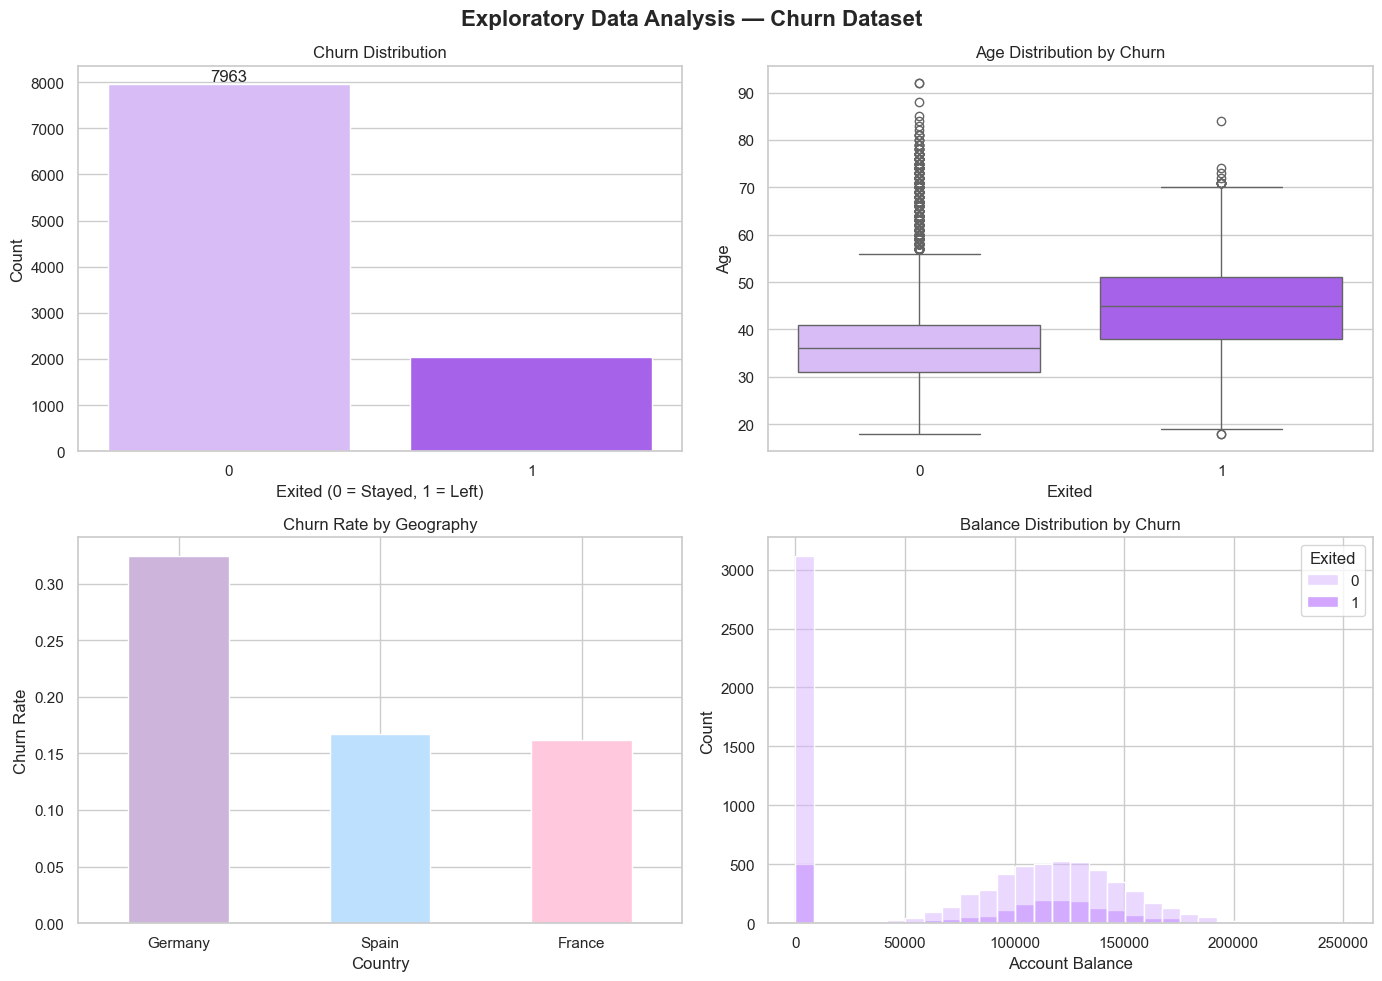

EDA plots saved.


In [3]:
#3 Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis — Churn Dataset", fontsize=16, fontweight="bold")

purple_palette = ["#d6b3ff", "#a64dff"]

# Plot 1: Churn distribution
sns.countplot(x="Exited", hue="Exited", data=df,
              palette=purple_palette, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Churn Distribution")
axes[0, 0].set_xlabel("Exited (0 = Stayed, 1 = Left)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].bar_label(axes[0, 0].containers[0])

# Plot 2: Age vs Churn
sns.boxplot(x="Exited", y="Age", hue="Exited", data=df,
            palette=purple_palette, legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Age Distribution by Churn")
axes[0, 1].set_xlabel("Exited")

# Plot 3: Geography vs Churn
geo_churn = df.groupby("Geography")["Exited"].mean().sort_values(ascending=False)
geo_churn.plot(kind="bar", color=["#cdb4db", "#bde0fe", "#ffc8dd"], ax=axes[1, 0])
axes[1, 0].set_title("Churn Rate by Geography")
axes[1, 0].set_ylabel("Churn Rate")
axes[1, 0].set_xlabel("Country")
axes[1, 0].tick_params(axis="x", rotation=0)

# Plot 4: Balance vs Churn
sns.histplot(
    data=df, x="Balance", hue="Exited",
    palette=purple_palette, bins=30,
    alpha=0.5, ax=axes[1, 1]
)
axes[1, 1].set_title("Balance Distribution by Churn")
axes[1, 1].set_xlabel("Account Balance")

plt.tight_layout()
plt.savefig("data/customer_churn_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved.")

## Data Preprocessing
We drop ID columns (no predictive value), encode categorical columns
(Geography, Gender) into numbers, split 80/20, and scale features
so Logistic Regression is not distorted by large value ranges.

In [4]:
#4 Data Preprocessing

# Step a: Drop irrelevant columns (IDs and names carry no predictive value)
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
print("Columns after dropping irrelevant ones:", df.columns.tolist())

# Step b: One-Hot Encode categorical columns
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)
print("\nColumns after encoding:", df.columns.tolist())
print("Shape now:", df.shape)

# Step c: Separate features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape:   {y.shape}")

# Step d: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y ensures churn ratio is preserved in both train and test sets

print(f"\nTraining samples:  {X_train.shape[0]}")
print(f"Testing samples:   {X_test.shape[0]}")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate:  {y_test.mean()*100:.2f}%")

# Step e: Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit ONLY on train data
X_test_scaled  = scaler.transform(X_test)       # Apply same scale to test data
print("Preprocessing complete.")

Columns after dropping irrelevant ones: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Columns after encoding: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
Shape now: (10000, 12)

Features shape: (10000, 11)
Target shape:   (10000,)

Training samples:  8000
Testing samples:   2000

Train churn rate: 20.38%
Test churn rate:  20.35%
Preprocessing complete.


## Model Training
We train three models of increasing complexity and compare them.
A single Decision Tree is fast but tends to overfit.
Random Forest fixes this by averaging 100 trees.

In [5]:
#5 Train and compare three models

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    report = classification_report(
        y_test, y_pred,
        target_names=["Stayed", "Churned"],
        output_dict=True
    )

    print(classification_report(
        y_test, y_pred,
        target_names=["Stayed", "Churned"]
    ))
    print(f"ROC-AUC Score: {auc:.4f}")

    results[name] = {
        "accuracy":  report["accuracy"],
        "precision": report["Churned"]["precision"],  
        "recall":    report["Churned"]["recall"],
        "f1":        report["Churned"]["f1-score"],
        "roc_auc":   auc,
        "model":     model
    }

print("All models trained.")


  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC-AUC Score: 0.7748

  Decision Tree
              precision    recall  f1-score   support

      Stayed       0.86      0.97      0.91      1593
     Churned       0.79      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC Score: 0.8423

  Random Forest
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83    

In [6]:
#6 Visual comparison of all models

comparison_df = pd.DataFrame({
    name: {
        "Accuracy":  f"{v['accuracy']*100:.1f}%",
        "Precision (Churn)": f"{v['precision']*100:.1f}%",
        "Recall (Churn)":    f"{v['recall']*100:.1f}%",
        "F1 (Churn)":        f"{v['f1']*100:.1f}%",
        "ROC-AUC":           f"{v['roc_auc']:.4f}"
    }
    for name, v in results.items()
}).T

print("Model Comparison Table:")
display(comparison_df)

Model Comparison Table:


,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Logistic Regression,80.8%,58.9%,18.7%,28.4%,0.7748
Decision Tree,85.6%,78.7%,40.0%,53.1%,0.8423
Random Forest,86.4%,78.2%,45.9%,57.9%,0.8522


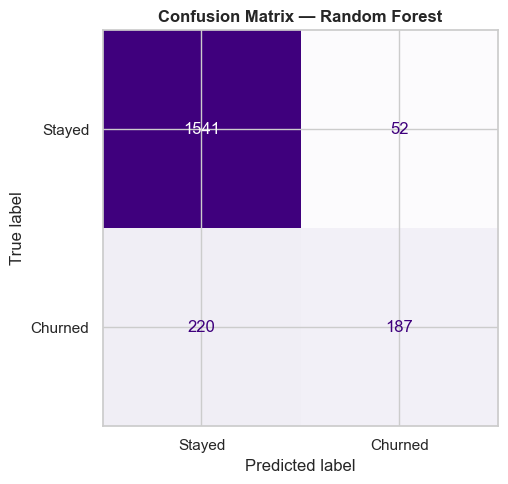

Confusion matrix saved.


In [7]:
#7 Confusion Matrix for Random Forest

best_model = results["Random Forest"]["model"]
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["Stayed", "Churned"],
    colorbar=False,
    cmap="Purples",
    ax=ax
)

ax.set_title("Confusion Matrix — Random Forest", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("data/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Confusion matrix saved.")

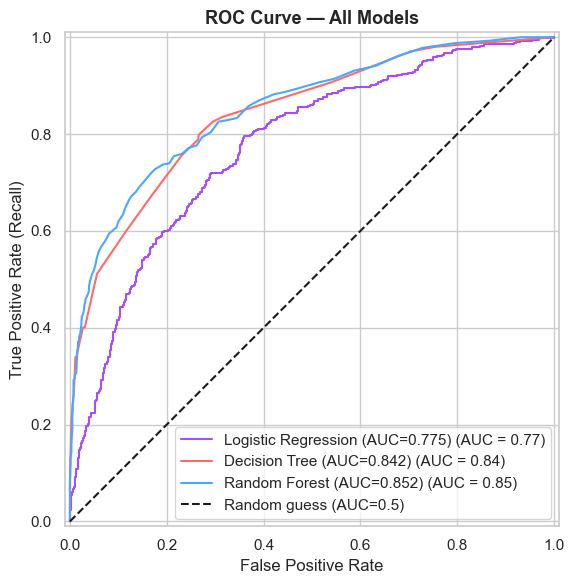

ROC curve saved.


In [8]:
#8 ROC Curve for all three models
fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#a64dff", "#ff6b6b", "#4da6ff"]

for (name, v), color in zip(results.items(), colors):
    RocCurveDisplay.from_estimator(
        v["model"], X_test_scaled, y_test,
        name=f"{name} (AUC={v['roc_auc']:.3f})",
        ax=ax,
        color=color  
    )

ax.plot([0, 1], [0, 1], "k--", label="Random guess (AUC=0.5)")

ax.set_title("ROC Curve — All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("data/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("ROC curve saved.")

## Feature Importance
Which features does the model rely on most?
This tells the bank why customers churn, not just who will churn.

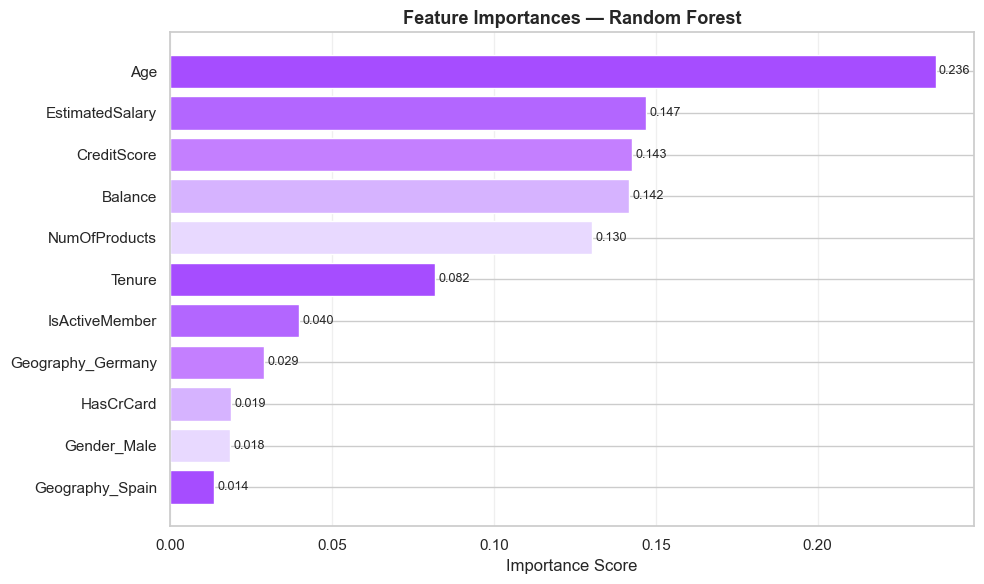


Top 5 most important features:
  1. Age: 0.2365
  2. EstimatedSalary: 0.1470
  3. CreditScore: 0.1428
  4. Balance: 0.1418
  5. NumOfProducts: 0.1304


In [9]:
#9 Feature Importance from Random Forest

feature_names  = X.columns.tolist()
importances     = best_model.feature_importances_
sorted_indices  = np.argsort(importances)[::-1]  # Descending order

sorted_features = [feature_names[i] for i in sorted_indices]
sorted_values   = importances[sorted_indices]

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#a64dff", "#b366ff", "#c47fff", "#d6b3ff", "#e8d9ff"]

# Repeat colors if features are more than 5
colors = (colors * (len(sorted_features) // len(colors) + 1))[:len(sorted_features)]

bars = ax.barh(sorted_features[::-1], sorted_values[::-1], color=colors[::-1])

ax.set_xlabel("Importance Score")
ax.set_title("Feature Importances — Random Forest", fontsize=13, fontweight="bold")

# Add value labels
for bar, val in zip(bars, sorted_values[::-1]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", alpha=0.3)  

plt.tight_layout()

plt.savefig("data/feature_importance.png", dpi=150, bbox_inches="tight")

plt.show()

print("\nTop 5 most important features:")
for i, (feat, imp) in enumerate(zip(sorted_features[:5], sorted_values[:5])):
    print(f"  {i+1}. {feat}: {imp:.4f}")